In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [ ]:
def add_noise(img, noise_factor=0.1):
    noisy_img = img + noise_factor * torch.randn(img.shape)
    # Ensure pixel values are in the valid range [0, 1]
    noisy_img = torch.clamp(noisy_img, 0., 1.)
    return noisy_img

In [188]:
noise_factor = .1

transform = transforms.Compose([
    transforms.Resize((32, 32)), 
    transforms.ToTensor(), 
    #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize
])

transform_noisy = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(), 
    transforms.Lambda(lambda img: img + noise_factor * torch.randn_like(img)),  # Add noise
    #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize
])

# Load Data

In [226]:

train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_noisy = datasets.MNIST(root='./data', train=True, download=True, transform=transform_noisy)
test_noisy = datasets.MNIST(root='./data', train=False, download=True, transform=transform_noisy)
print(f'Training set size: {train.data.shape}')

Training set size: torch.Size([60000, 28, 28])


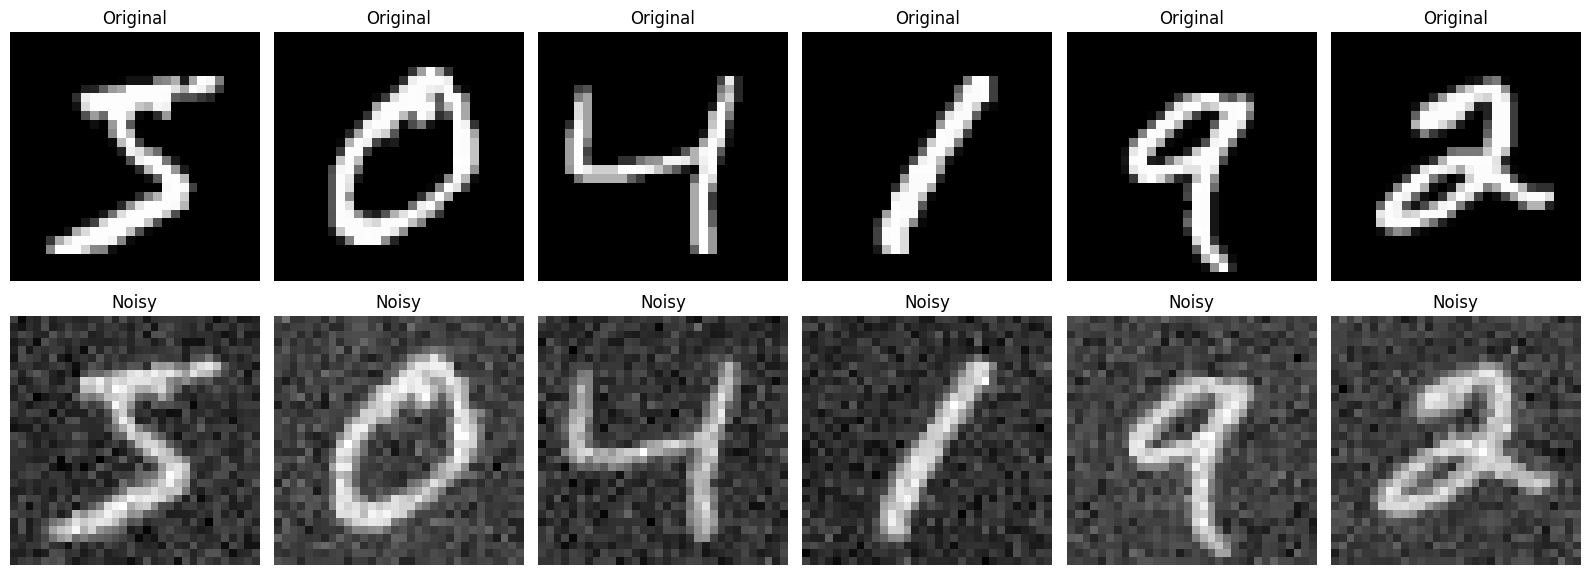

In [227]:
plots = 6
fig, ax = plt.subplots(2, plots, figsize=(16, 6))
count = 0

for i in range(plots):
    # Plot original image on top row
    ax[0, i].imshow(train[count][0].numpy().squeeze(), cmap='gray')
    ax[0, i].set_title('Original')
    ax[0, i].axis('off')
    
    # Plot noisy image on bottom row
    ax[1, i].imshow(train_noisy[count][0].numpy().squeeze(), cmap='gray')
    ax[1, i].set_title('Noisy')
    ax[1, i].axis('off')
    
    count += 1

plt.tight_layout()
plt.show()

In [191]:
data_loader = torch.utils.data.DataLoader(train_noisy, batch_size=64, shuffle=True)

data_iter = iter(data_loader)

noisy_images, labels = next(data_iter)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
Min pixel value: -1.0, Max pixel value: 1.0


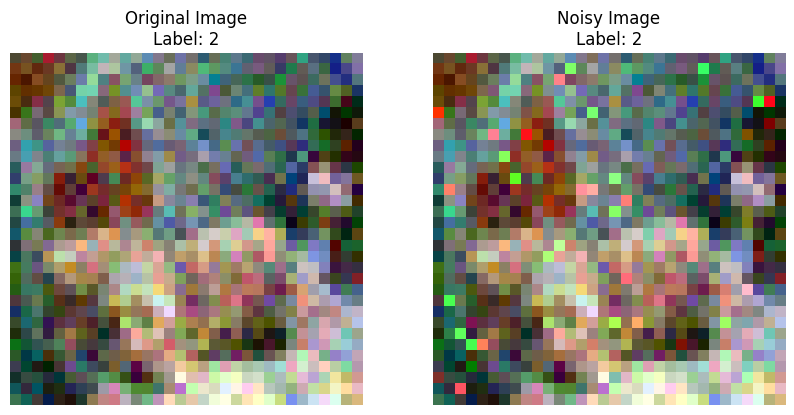

In [81]:
# Display Basic info of image and label
print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Min pixel value: {torch.min(images)}, Max pixel value: {torch.max(images)}')

# Get a single image
image = images[0]

# Add noise to the image
noisy_image = add_noise(image.to(device)).cpu()

# De-normalize function
def denormalize(img):
    img = img * 0.5 + 0.5  # De-normalize
    return img

# Show original image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(denormalize(image).permute(1, 2, 0))  # Change dimensions for display and de-normalize
plt.title(f'Original Image\nLabel: {labels[0]}')
plt.axis('off')

# Show noisy image
plt.subplot(1, 2, 2)
plt.imshow(denormalize(noisy_image).permute(1, 2, 0))  # Change dimensions for display and de-normalize
plt.title(f'Noisy Image\nLabel: {labels[0]}')
plt.axis('off')

plt.show()

In [209]:
class Autoencoder(nn.Module):
    def __init__(self, in_channels=3):
        # N, 1, 784 -> Batchsize, 28x28
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x) # encode x
        x = self.decoder(x) # decode encoded image
        return x

In [215]:
model = Autoencoder(in_channels=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [219]:
num_epochs = 3

for epoch in range(num_epochs):
    # training mode
    model.train()
    running_loss = 0.0
    
    for noisy_images, labels in data_loader:
        noisy_images = noisy_images.to(device)
        
        optimizer.zero_grad()

        outputs = model(noisy_images)
        
        loss = criterion(outputs, noisy_images)
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item() * noisy_images.size(0)
    
    epoch_loss = running_loss / len(train_noisy)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')


Epoch [1/3], Loss: 0.0466
Epoch [2/3], Loss: 0.0159
Epoch [3/3], Loss: 0.0137


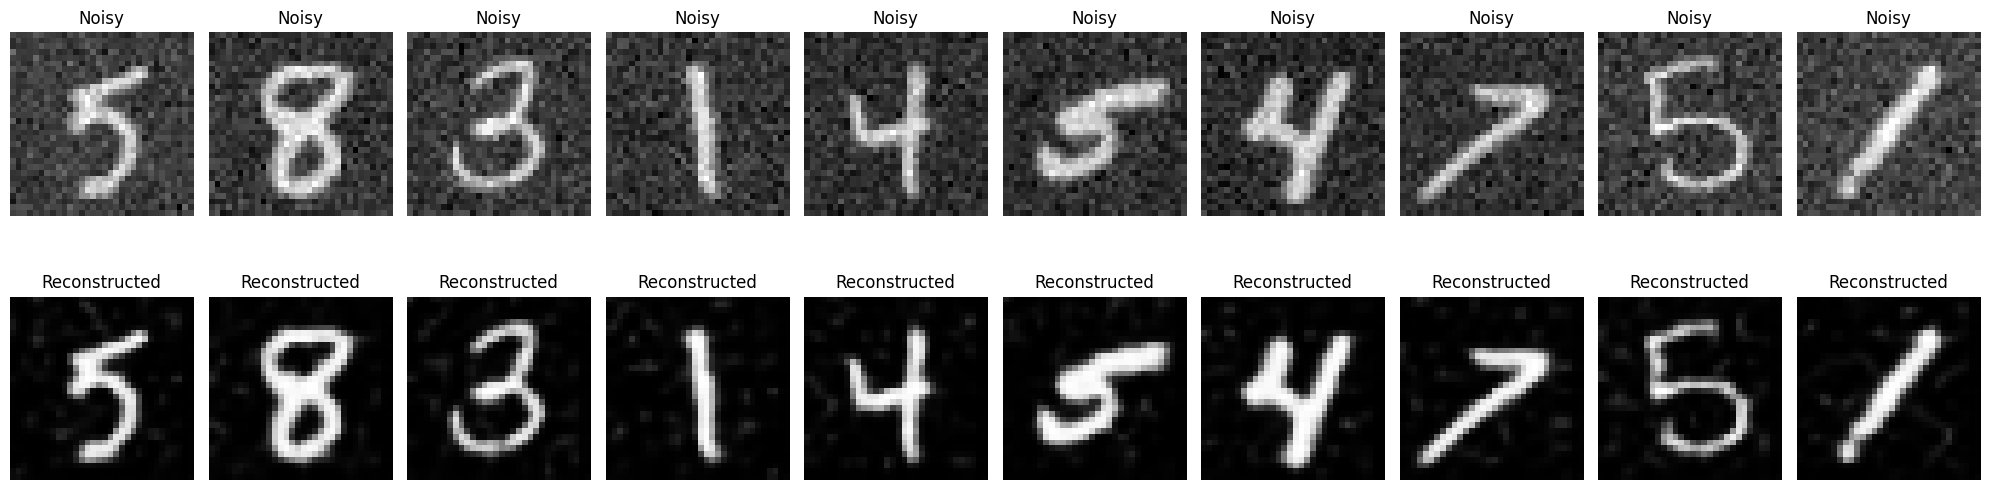

In [211]:
noisy_data_loader = torch.utils.data.DataLoader(train_noisy, batch_size=64, shuffle=True)
noisy_data_iter = iter(noisy_data_loader)

num_images = 10

fig, axes = plt.subplots(2, num_images, figsize=(20, 6))

for i in range(num_images):
    noisy_images, labels = next(noisy_data_iter)
    noisy_images = noisy_images.to(device)

    with torch.no_grad():  # Disable gradient computation during evaluation
        reconstructed_images = model(noisy_images)

    # Display noisy image
    axes[0, i].imshow(noisy_images[0].squeeze().cpu(), cmap='gray')
    axes[0, i].set_title('Noisy')

    # Display reconstructed image
    axes[1, i].imshow(reconstructed_images[0].squeeze().cpu(), cmap='gray')
    axes[1, i].set_title('Reconstructed')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()


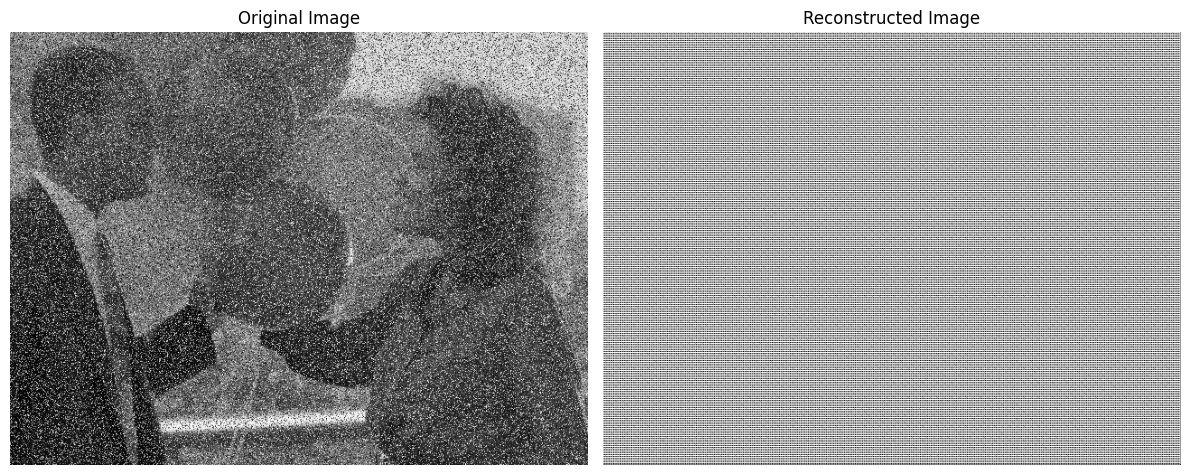

In [ ]:
image_path = './noisy2.png'  
image = Image.open(image_path).convert('L')  # Grayscale

transform = transforms.Compose([
    #transforms.Resize((32, 32)), 
    transforms.ToTensor()
])

original_image = transform(image)

image = original_image.unsqueeze(0).to(device)  # Add batch dimension and move to the same device

# Reconstruct image with trained model
model.eval() 
with torch.no_grad():
    reconstructed_image = model(image)

reconstructed_image = reconstructed_image.squeeze().cpu()

# Convert tensors to PIL images
original_image = transforms.ToPILImage()(original_image)
reconstructed_image = transforms.ToPILImage()(reconstructed_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(reconstructed_image, cmap='gray')
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()